# Final Project Notebook

Academic Track 2 notebook for stock movement prediction, model comparison, and backtesting.

Run this notebook from top to bottom. It uses the project scripts instead of duplicating their implementation, so the notebook remains presentation-friendly while the code stays maintainable.

Important: this project is an academic simulation only. It is not investment advice.

## Project Goal

The goal is to predict future stock movement as BUY / HOLD / SELL over a configurable horizon and evaluate the result using both statistical metrics and a trading-style backtest after costs.

This notebook runs the full Track 2 workflow:

1. Validate Python files.
2. Train the LSTM model.
3. Train the XGBoost model.
4. Compare model metrics and backtest metrics.
5. Run inference for a sample ticker.
6. Display demo-ready outputs.

## Setup

Change `HORIZON` or `SAMPLE_TICKER` if needed. Keep `RUN_TRAINING = True` for a full fresh run. If models already exist and you only want to inspect outputs, set it to `False`.

In [1]:
from pathlib import Path
import json
import os
import subprocess
import sys

import pandas as pd

ROOT = Path.cwd()
if not (ROOT / 'configs' / 'config.yaml').exists():
    ROOT = ROOT.parent
os.chdir(ROOT)

HORIZON = 10
SAMPLE_TICKER = 'AAPL'
RUN_TRAINING = True
INSTALL_REQUIREMENTS = True

print(f'Project root: {ROOT}')
print(f'Horizon: {HORIZON}')
print(f'Sample ticker: {SAMPLE_TICKER}')

Project root: c:\Users\יהונתן סגל\Projects\B.Sc - SISE\D - Forth year\Semester B\algo-trading-lstm-stock-prediction
Horizon: 10
Sample ticker: AAPL


In [2]:
def run_command(args, check=True):
    print('\n$ ' + ' '.join(str(a) for a in args))
    result = subprocess.run([str(a) for a in args], cwd=ROOT, text=True)
    if check and result.returncode != 0:
        raise RuntimeError(f'Command failed with exit code {result.returncode}: {args}')
    return result.returncode

if INSTALL_REQUIREMENTS:
    run_command([sys.executable, '-m', 'pip', 'install', '-r', 'requirements.txt'])


$ c:\Users\יהונתן סגל\Projects\B.Sc - SISE\D - Forth year\Semester B\algo-trading-lstm-stock-prediction\.venv\Scripts\python.exe -m pip install -r requirements.txt


## Validation

These checks confirm that the scripts and `src` package compile before running the heavier training workflow.

In [3]:
run_command([sys.executable, '-m', 'py_compile', 'train.py', 'train_xgboost.py', 'compare_results.py', 'compare_models.py', 'evaluate_saved_model.py', 'predict.py'])
run_command([sys.executable, '-m', 'compileall', 'src'])


$ c:\Users\יהונתן סגל\Projects\B.Sc - SISE\D - Forth year\Semester B\algo-trading-lstm-stock-prediction\.venv\Scripts\python.exe -m py_compile train.py train_xgboost.py compare_results.py compare_models.py evaluate_saved_model.py predict.py

$ c:\Users\יהונתן סגל\Projects\B.Sc - SISE\D - Forth year\Semester B\algo-trading-lstm-stock-prediction\.venv\Scripts\python.exe -m compileall src


0

## Data Loading

The training scripts download historical OHLCV data from Yahoo Finance for the configured stock universe, add SPY benchmark features, add macro / alternative indicators, and attach earnings features where available.

The current macro tickers are configured in `configs/config.yaml`: VIX, 10-year Treasury yield proxy, and USD index.

## Feature Engineering

The shared pipeline builds technical indicators, benchmark features, macro features, earnings features, and future-return labels. The split is chronological to avoid training on future data.

## LSTM Training

The LSTM is the sequential model. It uses rolling windows and has two heads: one for BUY / HOLD / SELL classification and one for future return regression.

In [4]:
if RUN_TRAINING:
    run_command([sys.executable, 'train.py', '--horizon', HORIZON])
else:
    print('Skipping LSTM training because RUN_TRAINING = False')


$ c:\Users\יהונתן סגל\Projects\B.Sc - SISE\D - Forth year\Semester B\algo-trading-lstm-stock-prediction\.venv\Scripts\python.exe train.py --horizon 10


## XGBoost Training

XGBoost is the second model family. It uses the same dataset pipeline and chronological split, then saves a classifier, regressor, metrics, predictions, and backtest results.

In [5]:
if RUN_TRAINING:
    run_command([sys.executable, 'train_xgboost.py', '--horizon', HORIZON])
else:
    print('Skipping XGBoost training because RUN_TRAINING = False')


$ c:\Users\יהונתן סגל\Projects\B.Sc - SISE\D - Forth year\Semester B\algo-trading-lstm-stock-prediction\.venv\Scripts\python.exe train_xgboost.py --horizon 10


## Model Comparison

This creates the comparison CSV and Markdown report under `reports/`.

In [6]:
run_command([sys.executable, 'compare_results.py', '--horizon', HORIZON])


$ c:\Users\יהונתן סגל\Projects\B.Sc - SISE\D - Forth year\Semester B\algo-trading-lstm-stock-prediction\.venv\Scripts\python.exe compare_results.py --horizon 10


0

In [7]:
comparison_path = ROOT / 'reports' / f'model_comparison_h{HORIZON}.csv'
comparison = pd.read_csv(comparison_path)
comparison

,metric,lstm,xgboost,delta_xgboost_minus_lstm,higher_is_better,winner
0,accuracy,0.298861,0.321899,0.023038,True,xgboost
1,return_mae,0.056711,0.066419,0.009708,False,lstm
2,total_return,0.000000,1.317341,1.317341,True,xgboost
3,buy_and_hold_total_return,7.642285,11.739569,4.097284,True,xgboost
4,excess_return_vs_buy_hold,-7.642285,-10.422229,-2.779944,True,lstm
5,max_drawdown,0.000000,-0.534710,-0.534710,False,xgboost
6,sharpe_ratio,0.000000,2.093258,2.093258,True,xgboost
7,sortino_ratio,0.000000,2.248076,2.248076,True,xgboost
8,win_rate,0.000000,0.592822,0.592822,True,xgboost
9,average_trade_return,0.000000,0.011289,0.011289,True,xgboost


## Evaluation Summaries

Print the saved statistical metrics, backtest metrics, and signal distribution for each model.

In [8]:
run_command([sys.executable, 'evaluate_saved_model.py', '--model', 'lstm', '--horizon', HORIZON])
run_command([sys.executable, 'evaluate_saved_model.py', '--model', 'xgboost', '--horizon', HORIZON])


$ c:\Users\יהונתן סגל\Projects\B.Sc - SISE\D - Forth year\Semester B\algo-trading-lstm-stock-prediction\.venv\Scripts\python.exe evaluate_saved_model.py --model lstm --horizon 10

$ c:\Users\יהונתן סגל\Projects\B.Sc - SISE\D - Forth year\Semester B\algo-trading-lstm-stock-prediction\.venv\Scripts\python.exe evaluate_saved_model.py --model xgboost --horizon 10


0

## EDA

After training, the processed dataset can be inspected directly. This gives a quick view of rows, date coverage, tickers, label balance, and return distribution.

In [9]:
dataset_path = ROOT / 'data' / 'processed' / f'full_dataset_h{HORIZON}.csv'
df = pd.read_csv(dataset_path, parse_dates=['Date'] if 'Date' in pd.read_csv(dataset_path, nrows=0).columns else None)

date_col = 'Date' if 'Date' in df.columns else df.columns[0]
df[date_col] = pd.to_datetime(df[date_col])

summary = {
    'rows': len(df),
    'columns': len(df.columns),
    'start_date': str(df[date_col].min().date()),
    'end_date': str(df[date_col].max().date()),
    'tickers': ', '.join(sorted(df['Ticker'].unique())) if 'Ticker' in df.columns else 'n/a',
}
pd.DataFrame([summary])

,rows,columns,start_date,end_date,tickers
0,26843,69,2015-10-16,2026-06-23,"AAPL, AMZN, GOOGL, JPM, META, MSFT, NVDA, TSLA..."


In [10]:
label_names = {0: 'SELL', 1: 'HOLD', 2: 'BUY'}
label_counts = df['signal_label'].map(label_names).value_counts().rename_axis('label').reset_index(name='count')
label_counts['share'] = label_counts['count'] / label_counts['count'].sum()
label_counts

,label,count,share
0,HOLD,11484,0.427821
1,BUY,9424,0.351078
2,SELL,5935,0.221100


In [11]:
df[['future_return']].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])

,future_return
count,26843.000000
mean,0.011505
std,0.070664
min,-0.518052
5%,-0.097557
25%,-0.024117
50%,0.011156
75%,0.045959
95%,0.119578
max,0.658833


## Backtest Comparison

The backtest treats each prediction as an academic simulated trade over the selected horizon, subtracts transaction cost and slippage, and compares performance against buy-and-hold.

In [12]:
lstm_backtest = pd.read_csv(ROOT / 'reports' / f'backtest_results_h{HORIZON}.csv')
xgb_backtest = pd.read_csv(ROOT / 'reports' / f'backtest_results_xgboost_h{HORIZON}.csv')

display(lstm_backtest.tail())
display(xgb_backtest.tail())

,date,strategy_return,active_trades,average_confidence,average_true_return,equity,buy_and_hold_equity,running_max,drawdown
338,2026-06-16,0.0,0,0.424325,-0.004960,10000.0,78741.606053,10000.0,0.0
339,2026-06-17,0.0,0,0.418160,0.009787,10000.0,79512.252525,10000.0,0.0
340,2026-06-18,0.0,0,0.422789,0.015519,10000.0,80746.230831,10000.0,0.0
341,2026-06-22,0.0,0,0.431963,0.034514,10000.0,83533.072231,10000.0,0.0
342,2026-06-23,0.0,0,0.432401,0.034594,10000.0,86422.849002,10000.0,0.0


,date,strategy_return,active_trades,average_confidence,average_true_return,equity,buy_and_hold_equity,running_max,drawdown
398,2026-06-16,0.0,0,0.680647,-0.004960,23173.407505,116072.792773,27043.163339,-0.143096
399,2026-06-17,0.0,0,0.680115,0.009787,23173.407505,117208.800700,27043.163339,-0.143096
400,2026-06-18,0.0,0,0.768655,0.015519,23173.407505,119027.804891,27043.163339,-0.143096
401,2026-06-22,0.0,0,0.783256,0.034514,23173.407505,123135.880399,27043.163339,-0.143096
402,2026-06-23,0.0,0,0.760127,0.034594,23173.407505,127395.692644,27043.163339,-0.143096


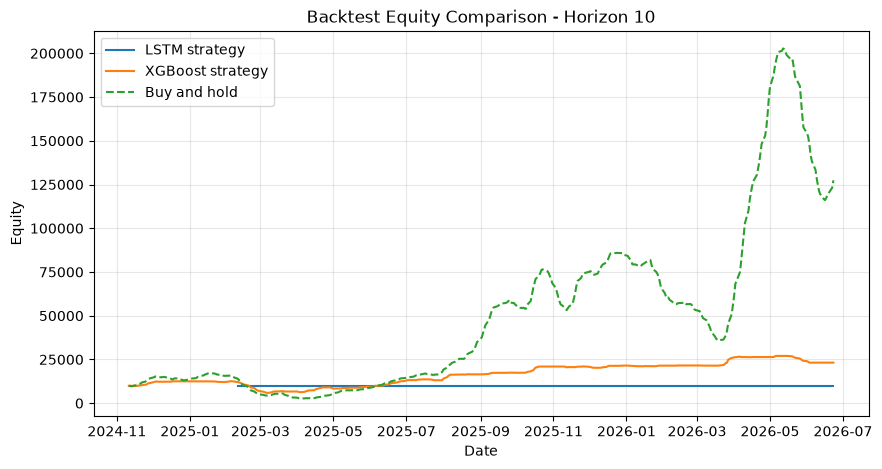

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(pd.to_datetime(lstm_backtest['date']), lstm_backtest['equity'], label='LSTM strategy')
plt.plot(pd.to_datetime(xgb_backtest['date']), xgb_backtest['equity'], label='XGBoost strategy')
plt.plot(pd.to_datetime(xgb_backtest['date']), xgb_backtest['buy_and_hold_equity'], label='Buy and hold', linestyle='--')
plt.title(f'Backtest Equity Comparison - Horizon {HORIZON}')
plt.xlabel('Date')
plt.ylabel('Equity')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Inference

Run one prediction using the trained LSTM artifacts and the same inference feature pipeline.

In [14]:
run_command([sys.executable, 'predict.py', '--ticker', SAMPLE_TICKER, '--horizon', HORIZON])
pd.read_csv(ROOT / 'reports' / 'latest_predictions.csv')


$ c:\Users\יהונתן סגל\Projects\B.Sc - SISE\D - Forth year\Semester B\algo-trading-lstm-stock-prediction\.venv\Scripts\python.exe predict.py --ticker AAPL --horizon 10


,ticker,latest_data_date,prediction_horizon_trading_days,signal,expected_return,expected_return_pct,raw_expected_return,raw_expected_return_pct,return_was_aligned_to_signal,prob_sell,prob_hold,prob_buy,confidence
0,AAPL,2026-07-08,10,SELL,-0.016877,-1.687695,-0.016877,-1.687695,False,0.400405,0.302777,0.296818,0.400405


## Output Files

The main demo-ready files are listed below.

In [15]:
outputs = [
    ROOT / 'models' / f'stock_advanced_model_h{HORIZON}.pt',
    ROOT / 'models' / f'xgboost_classifier_h{HORIZON}.joblib',
    ROOT / 'models' / f'xgboost_regressor_h{HORIZON}.joblib',
    ROOT / 'reports' / f'metrics_h{HORIZON}.json',
    ROOT / 'reports' / f'metrics_xgboost_h{HORIZON}.json',
    ROOT / 'reports' / f'model_comparison_h{HORIZON}.csv',
    ROOT / 'reports' / f'model_comparison_h{HORIZON}.md',
    ROOT / 'reports' / f'backtest_results_h{HORIZON}.csv',
    ROOT / 'reports' / f'backtest_results_xgboost_h{HORIZON}.csv',
]

pd.DataFrame({'file': [str(path.relative_to(ROOT)) for path in outputs], 'exists': [path.exists() for path in outputs]})

,file,exists
0,models\stock_advanced_model_h10.pt,True
1,models\xgboost_classifier_h10.joblib,True
2,models\xgboost_regressor_h10.joblib,True
3,reports\metrics_h10.json,True
4,reports\metrics_xgboost_h10.json,True
5,reports\model_comparison_h10.csv,True
6,reports\model_comparison_h10.md,True
7,reports\backtest_results_h10.csv,True
8,reports\backtest_results_xgboost_h10.csv,True


## Risks and Future Work

- Yahoo Finance data can be delayed, revised, incomplete, or unavailable for some tickers.
- The backtest is simplified and does not model market impact, order-book dynamics, liquidity, or production risk controls.
- Results can be unstable across horizons and market regimes.
- Future work can add walk-forward validation, stronger risk management, richer alternative data, and additional model families.

Academic disclaimer: this notebook is for research and simulation only. It is not investment advice.